# Implementing an ODE model in Pymob

In this tutorial, we will implement a simple ODE model, create simulation results and infer an unknown parameter from artificially generated data. It is recommended to work through this notebook after the introductiory tutorial where something very similar is done for a linear regression model.

After setting up the simulation manually (Chapter 1), we will save our settings and create a new simulation from those settings (Chapter 2).

# Chapter 1: Setting up the model 👩‍💻

👉 Let's begin with setting up a Pymob simulation for an ODE model. This will follow roughly the same procedure as the introductory tutorial. We do, however, need to make some tweaks to allow for the needs of an ODE model.

In [1]:
# First, import the necessary python packages
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from scipy.integrate import solve_ivp

# Import the pymob modules
from pymob.simulation import SimulationBase
from pymob.solvers.diffrax import JaxSolver
from pymob.sim.config import Param, DataVariable

## 1.1 Creating the `sim` object 🧩

👉 As an example for a relatively simple ODE model, we will use the well-known **Lotka-Volterra model** describing a predator-prey relationship.

👉 The equations for this model look like this ($X$ and $Y$ denote prey and predator, respectively):

$\frac{dX}{dt} = \alpha X - \beta X Y$

$\frac{dY}{dt} = \gamma X Y - \delta Y$

$\newline \alpha, \beta, \gamma, \delta > 0$

👉 In the following cell, we will define our model. To work with our solver (we will later use {class}`pymob.solvers.diffrax.JaxSolver` which calls `diffrax.diffeqsolve`), our Python function needs to have a signature of the form `fun(t, y, *args)` where `t` represents the current time within the system, `y` represents the current system state and `*args` is a placeholder for all model parameters.

👉 Note that the argument `t` is not used inside the function as the derivatives generated by the Lotka Volterra model are independent from time. It still needs to be included in the signature to satisfy the needs of the solver.

In [2]:
def lotkavolterra(t, y, alpha, beta, gamma, delta):
    X, Y = y
    dXdt = alpha * X - beta * X * Y
    dYdt = gamma * X * Y - delta * Y
    return dXdt, dYdt

👉 We can then create our simulation object and assign the model and the solver to it:

In [3]:
# Initialize the simulation object
sim = SimulationBase()

# Configure the case study
sim.config.case_study.name = "ODEtutorial"
sim.config.case_study.scenario = "lotkavolterra"

# Add the model to the simulation
sim.model = lotkavolterra

# Define a solver
sim.solver = JaxSolver

## 1.2 Generating artificial data 📈

👉 Now we generate some artificial data that we will later use as our **observations**. To do this, we generate a time series of the Lotka-Volterra model with parameters $\alpha = 0.7, \beta = 0.1, \gamma = 0.1, \delta = 0.9$ from the initial condition $X = 10, Y = 5$ using `solve_ivp` (we could also use `diffrax.diffeqsolve` here, that would make no difference). This is done for 101 steps with $\Delta t = 0.5$.

👉 We then add some noise to the data and make sure that predator and prey abundances in our data are always positive as negative abundances would never be measured in reality.

👉 After running the code, you can take a look at our artificial data and recognize the characteristic periodic oscillations produced by the Lotka-Volterra model.

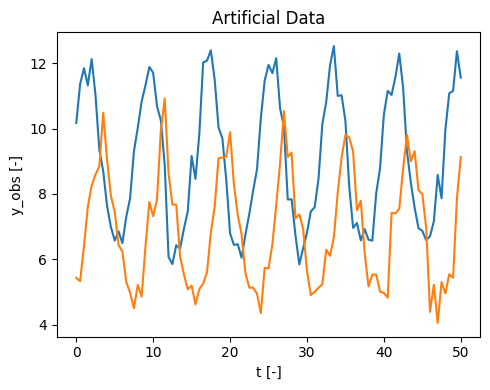

In [4]:
# Generate Lotka Volterra time series
sol = solve_ivp(lotkavolterra, (0, 50), np.array([10,5]), "LSODA", np.linspace(0,50,101), args=[0.7,0.1,0.1,0.9])

# Add "random" noise (example is made reproducible by setting a fixed seed)
rng = np.random.default_rng(seed=1)
noise = rng.normal(0, 0.5, (2,101))
y_obs = sol.y + noise
y_obs = np.greater(y_obs, np.zeros(y_obs.shape)) * y_obs

# Save the evaluated time points
t = sol.t

# Plot the generated data
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(t, y_obs.transpose(), label='Datapoints')
ax.set(xlabel='t [-]', ylabel='y_obs [-]', title ='Artificial Data')
plt.tight_layout()

## 1.3 Adding data to the `sim` object 🤝

👉 Let's prepare our observations. As seen in the introductory tutorial, Pymob uses `xArray` datasets. Because our model has two state variables, the dataset containing our artificial data also needs to have two data variables. It also needs to include the time points we generated the data for as a coordinate axis. This can be achieved like this (or probably in an easier way):

In [5]:
# Create an xArray dataset containing the artificial data
data_obs_1 = xr.DataArray(y_obs[0], coords={"time": t}).to_dataset(name="prey")
data_obs_2 = xr.DataArray(y_obs[1], coords={"time": t}).to_dataset(name="predator")
data_obs = xr.merge([data_obs_1, data_obs_2])

# Look at the structure of the generated datatset
data_obs

<xarray.Dataset>
Dimensions:   (time: 101)
Coordinates:
  * time      (time) float64 0.0 0.5 1.0 1.5 2.0 ... 48.0 48.5 49.0 49.5 50.0
Data variables:
    prey      (time) float64 10.17 11.36 11.85 11.33 ... 11.08 11.16 12.37 11.56
    predator  (time) float64 5.431 5.33 6.397 7.604 ... 5.544 5.436 7.871 9.127

👉 As our next step, we add our artificial data to the model. As you can see in the cell output, Pymob automatically detects the two data variables and the time axis and creates two {class}`pymob.sim.config.DataVariable` objects within the simulation's {class}`pymob.sim.config.DataStructure` instance. That's why it's so important to prepare the data in the way we did above!

In [6]:
# Add our dataset to the simulation
sim.observations = data_obs

# Take a look at the layout of the data
sim.config.data_structure

MinMaxScaler(variable=prey, min=5.844172888098338, max=12.52594869826619)
MinMaxScaler(variable=predator, min=4.053933700151361, max=10.925258075625722)


C:\Users\Markus\pymob\pymob\pymob\simulation.py:303: UserWarning: `sim.config.data_structure.prey = Datavariable(dimensions=['time'] min=5.844172888098338 max=12.52594869826619 observed=True dimensions_evaluator=None)` has been assumed from `sim.observations`. If the order of the dimensions should be different, specify `sim.config.data_structure.prey = DataVariable(dimensions=[...], ...)` manually.
  warnings.warn(
C:\Users\Markus\pymob\pymob\pymob\simulation.py:303: UserWarning: `sim.config.data_structure.predator = Datavariable(dimensions=['time'] min=4.053933700151361 max=10.925258075625722 observed=True dimensions_evaluator=None)` has been assumed from `sim.observations`. If the order of the dimensions should be different, specify `sim.config.data_structure.predator = DataVariable(dimensions=[...], ...)` manually.
  warnings.warn(


Datastructure(prey=DataVariable(dimensions=['time'], min=5.844172888098338, max=12.52594869826619, observed=True, dimensions_evaluator=None), predator=DataVariable(dimensions=['time'], min=4.053933700151361, max=10.925258075625722, observed=True, dimensions_evaluator=None))

👉 Because the results of ODE models strongly depend on their **initial conditions**, our simulation object need to know those. The correct place to put this information is {attr}`~pymob.sim.model_parameters["y0"]`.

👉 The initial conditions also have to be an xArray dataset with two data variables (but without the time coordinate). We can do this manually like before by creating a {class}`xArray.Dataset` object from our initial conditions:

In [7]:
# Create an xArray dataset
y0_obs_1 = xr.DataArray(10).to_dataset(name="prey")
y0_obs_2 = xr.DataArray(5).to_dataset(name="predator")
y0_obs = xr.merge([y0_obs_1, y0_obs_2])

# Add the initial condition to the simulation
sim.model_parameters["y0"] = y0_obs

```{admonition} Using parse_input()
:class: note
Otherwise we can use {method}`pymob.sim.parse_input()` which extracts all the necessary information from the configuration. This is, however, only possible after we give add this information to the configuration. This might seem unnecessary at the moment but you will later see why it makes sense in certain situations.
```

In [8]:
# Pass the initial condition to the simulation
#
# Note: The input needs to be a list containing a separate string for every state variable.
#       Those strings must have the format "variableName=initialValue" (without any spaces!).
sim.config.simulation.y0 = ["prey=10", "predator=5"]

# Let parse_input() create an xArray dataset
#
# Note: The input variable drop_dims makes sure that the dataset only contains a single value
#       instead of a full time series filled with the same value over and over again.
y0_obs = sim.parse_input("y0", drop_dims=['time'])

# Add the initial condition to the simulation
sim.model_parameters["y0"] = y0_obs

## 1.4 Setting parameters and running the model 👟

👉 The next step is defining the **parameters** of the system, similarly as in the introductiory tutorial. In this case, we want to have three fixed parameters ($\alpha = 0.7, \beta = 0.1, \gamma = 0.1$) and a single free parameter ($\delta$). You will soon see why we made that choice.

In [9]:
# Parameterize the model
sim.config.model_parameters.alpha = Param(value=0.7, free=False)
sim.config.model_parameters.beta = Param(value=0.1, free=False)
sim.config.model_parameters.gamma = Param(value=0.1, free=False)
sim.config.model_parameters.delta = Param(value=0.9, free=True)

# Make sure the model parameters are available to the model
sim.model_parameters["parameters"] = sim.config.model_parameters.value_dict

# Look at the parameter values passed to the model
sim.model_parameters["parameters"]

{'alpha': 0.7, 'beta': 0.1, 'gamma': 0.1, 'delta': 0.9}

👉 We do not need to define {attr}`~pymob.sim.model_parameters["x_in"]` as we don't wave any input data in this case. If we wanted to make the growth rates in our model depend on weather conditions and use a corresponding dataset, {attr}`~pymob.sim.model_parameters["x_in"]` would be the place to include our external data.

👉 Instead, we follow the same routine as in the introductory tutorial, let Pymob initialize the simulation and look at the resulting time series (with $\delta = 0.9$):

C:\Users\Markus\pymob\pymob\pymob\simulation.py:552: UserWarning: The number of ODE states was not specified in the config file [simulation] > 'n_ode_states = <n>'. Extracted the return arguments ['dXdt', 'dYdt'] from the source code. Setting 'n_ode_states=2.
  warnings.warn(


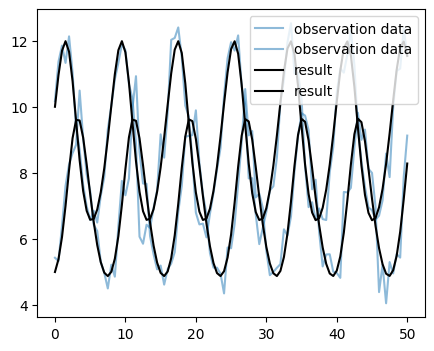

In [10]:
# Put everything in place for running the simulation
sim.dispatch_constructor()

# Create an evaluator, run the simulation and obtain the results
evaluator = sim.dispatch(theta={"delta":0.9})
evaluator()
data_res = evaluator.results

# Plot the results
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(data_obs.time, data_obs.prey, ls="-", color="tab:blue", alpha=.5, label ="observation data")
ax.plot(data_obs.time, data_obs.predator, ls="-", color="tab:blue", alpha=.5, label ="observation data")
ax.plot(data_res.time, data_res.prey, color="black", label ="result")
ax.plot(data_res.time, data_res.predator, color="black", label ="result")
ax.legend()

## 1.5 Finding out the value of $\delta$ 🔎

👉 Now let's see which value for $\delta$ best fits our data. To do that, we use the **inferer** in the same way as in the introductory tutorial. We do, however, need to apply our error model to both of our state variables. Also, we changed the prior for $\delta$ to a uniform distribution from 0.5 to 1.5 because that's a better guess.

```{admonition} Caution
:class: caution
The following code will throw an error. This is not your fault, just look at the error message and continue with the next markdown cell.
```

In [11]:
from jaxlib.xla_extension import XlaRuntimeError

In [12]:
# Add parameters to use in our error model
sim.config.model_parameters.sigma_prey = Param(free=True , prior="lognorm(scale=1,s=1)", min=0, max=1)
sim.config.model_parameters.sigma_predator = Param(free=True , prior="lognorm(scale=1,s=1)", min=0, max=1)

# Define the error model for both state variables
sim.config.error_model.prey = "normal(loc=prey,scale=sigma_prey)"
sim.config.error_model.predator = "normal(loc=predator,scale=sigma_predator)"

# Choose a prior distribution for delta
sim.config.model_parameters.delta.prior = "uniform(loc=0.5,scale=1)"

try:

    # Create the inferer (NumPyro backend, NUTS kernel) and let it do its work
    sim.set_inferer("numpyro")
    sim.inferer.config.inference_numpyro.kernel = "nuts"
    sim.inferer.run()

    # Plot the results
    sim.config.simulation.x_dimension = "time"
    sim.posterior_predictive_checks(pred_hdi_style={"alpha": 0.1})

except XlaRuntimeError as e:

    # Print the error message
    print("An error occurred:", type(e).__name__, ":", e)

Jax 64 bit mode: False
Absolute tolerance: 1e-07


C:\Users\Markus\pymob\pymob\pymob\inference\numpyro_backend.py:552: UserWarning: Model is not rendered, because the graphviz executable is not found. Try search for 'graphviz executables not found' and the used OS. This should be an easy fix :-)
  warnings.warn(


      Trace Shapes:      
       Param Sites:      
      Sample Sites:      
         delta dist     |
              value     |
    sigma_prey dist     |
              value     |
sigma_predator dist     |
              value     |
      prey_obs dist 101 |
              value 101 |
  predator_obs dist 101 |
              value 101 |
An error occurred: XlaRuntimeError : INTERNAL: Generated function failed: CpuCallback error: _EquinoxRuntimeError: The maximum number of solver steps was reached. Try increasing `max_steps`.


--------------------
An error occurred during the runtime of your JAX program! Unfortunately you do not appear to be using `equinox.filter_jit` (perhaps you are using `jax.jit` instead?) and so further information about the error cannot be displayed. (Probably you are seeing a very large but uninformative error message right now.) Please wrap your program with `equinox.filter_jit`.
--------------------


At:
  c:\Users\Markus\anaconda3\envs\pymob2\Lib\site-packages

👉 What you see is an error that originated during runtime. The error message should tell you:

`_EquinoxRuntimeError: The maximum number of solver steps was reached. Try increasing 'max_steps'.`

👉 This means that our solver has to deal with a very difficult problem. To accomodate that, it needs to be very precise and work with extremely small time steps which causes it to exceed the maximum number of steps it is allowed to take.

👉 We can solve this in two ways:

1. Increase {attr}`~pymob.sim.config.max_steps`: The simplest work to deal with this problem. It might not always work, though, because with very extreme model dynamics, even a high number of steps can be exceeded.

2. Set {attr}`~pymob.sim.config.throw_exception` to `False`: With this setting, exceeding the maximum number of steps will not result in an error but return `inf` values as the result. In that case, the loss would also be infinite and the corresponding value of $\delta$ would simply be rejected. That means that difficult problems are being thrown out and we make our decision about $\delta$ based on the remaining runs. In many cases, extreme model behavior resulting in {attr}`~pymob.sim.config.max_steps` being exceeded will not fit the data anyway and rejecting the corresponding parameter value is justified. But to make such an assumption, you should know your system very well and check whether the assumption is valid.

👉 We will first try option 1:

In [13]:
# Increase max_steps
sim.config.jaxsolver.max_steps = 100000000

# Put everything in place (needs to be run again because we changed an important setting)
sim.dispatch_constructor()

try:

    # Try running the inferer again
    sim.inferer.run()

    # Plot the results
    sim.config.simulation.x_dimension = "time"
    sim.posterior_predictive_checks(pred_hdi_style={"alpha": 0.1})

except XlaRuntimeError as e:

    # Print the error message
    print("An error occurred:", type(e).__name__, ":", e)

      Trace Shapes:      
       Param Sites:      
      Sample Sites:      
         delta dist     |
              value     |
    sigma_prey dist     |
              value     |
sigma_predator dist     |
              value     |
      prey_obs dist 101 |
              value 101 |
  predator_obs dist 101 |
              value 101 |
An error occurred: XlaRuntimeError : INTERNAL: Generated function failed: CpuCallback error: _EquinoxRuntimeError: The maximum number of solver steps was reached. Try increasing `max_steps`.


--------------------
An error occurred during the runtime of your JAX program! Unfortunately you do not appear to be using `equinox.filter_jit` (perhaps you are using `jax.jit` instead?) and so further information about the error cannot be displayed. (Probably you are seeing a very large but uninformative error message right now.) Please wrap your program with `equinox.filter_jit`.
--------------------


At:
  c:\Users\Markus\anaconda3\envs\pymob2\Lib\site-packages

👉 Even with {attr}`~pymob.sim.config.max_steps` set to 100.000.000 (the default value is 4096), we still get a runtime error, it just needs a little longer to appear. That means that we probably have an extremely sensitive numerical problem for some of our prior values, exceeding even an unreasonable amount of solver steps. So let's try option 2:

      Trace Shapes:      
       Param Sites:      
      Sample Sites:      
         delta dist     |
              value     |
    sigma_prey dist     |
              value     |
sigma_predator dist     |
              value     |
      prey_obs dist 101 |
              value 101 |
  predator_obs dist 101 |
              value 101 |


sample: 100%|██████████| 3000/3000 [00:15<00:00, 188.91it/s, 15 steps of size 4.32e-01. acc. prob=0.93]



                      mean       std    median      5.0%     95.0%     n_eff     r_hat
           delta      0.90      0.00      0.90      0.89      0.90   2707.28      1.00
  sigma_predator      0.52      0.04      0.52      0.46      0.58   1255.02      1.00
      sigma_prey      0.44      0.03      0.43      0.39      0.49   1217.63      1.00

Number of divergences: 0


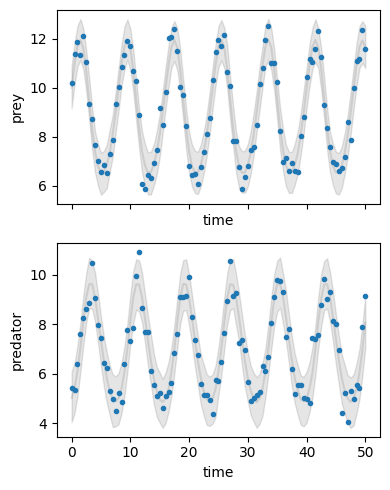

In [14]:
# Decrease max_steps to a reasonable value and set throw_exception to False
sim.config.jaxsolver.max_steps = 10000
sim.config.jaxsolver.throw_exception = False

# Put everything in place (needs to be run again because we changed an important setting)
sim.dispatch_constructor()

try:

    # Try running the inferer again
    sim.inferer.run()

    # Plot the results
    sim.config.simulation.x_dimension = "time"
    sim.posterior_predictive_checks(pred_hdi_style={"alpha": 0.1})

except XlaRuntimeError as e:

    # Print the error message
    print("An error occurred:", type(e).__name__, ":", e)

👉 This worked, so now we can have a look at the results:

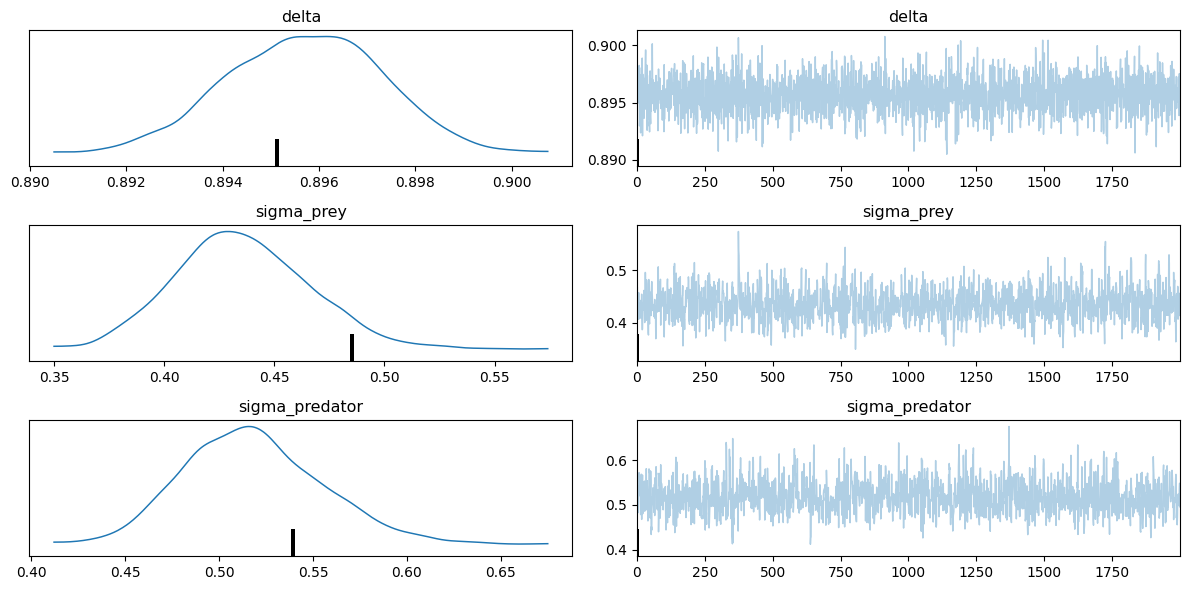

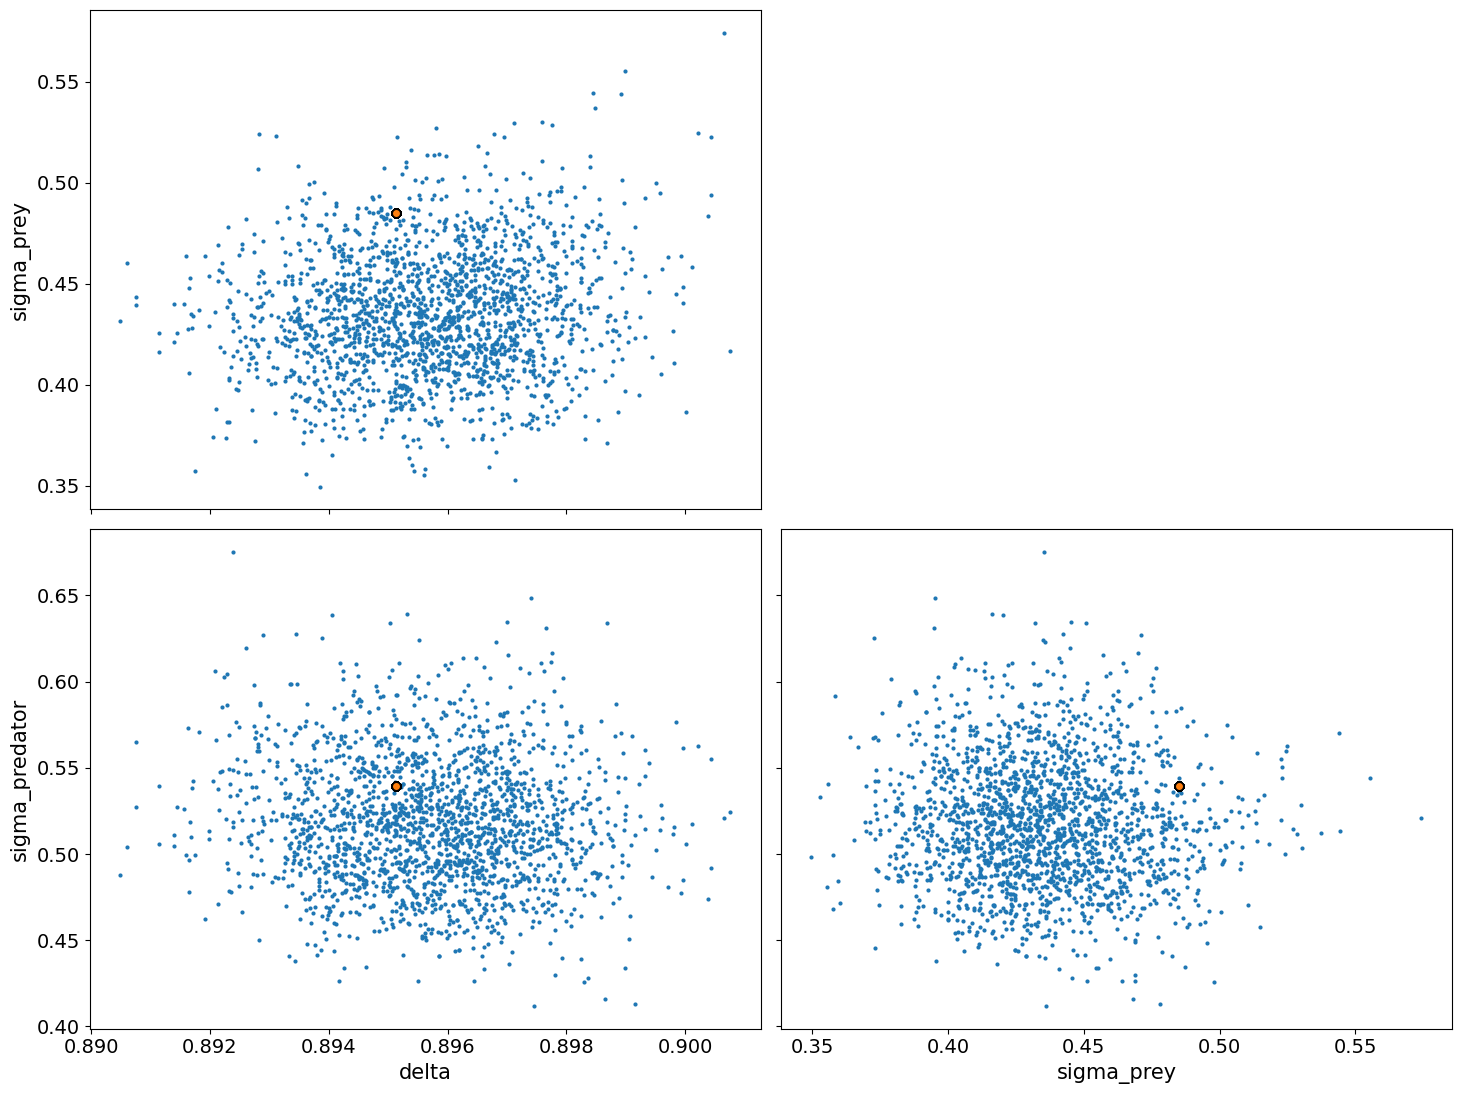

In [15]:
# Report the results
sim.report()

# Chapter 2: Saving and retrieving a simulation 💾

👉 In this chapter, we will save our Pymob simulation and create a new simulation from it. You will see that this makes the process much shorter than above.

👉 Let's start by **saving** our configuration and observations.

```{admonition} Caution
:class: caution
The observations have to be saved before the configuration. Otherwise the configuration doesn't save the location the observations were saved in which causes problems down the line.
```

In [16]:
# Set the data paths we want to save to and create the necessary folders if they don't exist yet
import os
sim.config.create_directory("scenario", force=True)
sim.config.create_directory("results", force=True)
os.makedirs(sim.data_path, exist_ok=True)

# Save our configuration and observations
sim.save_observations(force=True)
sim.config.save(force=True)

Scenario directory exists at 'c:\Users\Markus\pymob\pymob\docs\source\user_guide\case_studies\ODEtutorial\scenarios\lotkavolterra'.
Results directory exists at 'c:\Users\Markus\pymob\pymob\docs\source\user_guide\case_studies\ODEtutorial\results\lotkavolterra'.


## 2.1 Creating a new `sim` file from a saved configuration 🆕

👉 In the next part we try to generate a new simulation object from the configuration file we just created. To do this, we first have to make an additional import:

In [17]:
from pymob import Config

👉 After we've done that, we can now create a {class}`pymob.config.Config` object from our file. This can then be passed to the constructor of {class}`pymob.SimulationBase`. 

In [18]:
# Load configuration to a Config instance
config = Config("case_studies/ODEtutorial/scenarios/lotkavolterra/settings.cfg")

# Create a new simulation from the configuration
sim2 = SimulationBase(config)

👉 Essentially, passing the {class}`pymob.config.Config` file to the {class}`pymob.SimulationBase` constructor just copies it to {attr}`~pymob.sim2.config`.

In [19]:
config == sim2.config

True

👉 Now that our simulation knows about its configuration, we can call the {meth}`pymob.sim.SimulationBase.initialize()` function which prepares all of our data for us. It fetches the observation data from the specified location and handles the initial condition as well as external inputs (which we don't have here). That means that a well-prepared config file can save a lot of work!

👉 We do, however, still need to specify some additional features of the {class}`pymob.sim.SimulationBase` object. That includes the model, its parameters and the solver.

```{admonition} Subclassing SimulationBase
:class: note
By subclassing {class}`pymob.SimulationBase` and writing a customized `initialize()` function that also includes these tasks, this can be avoided (see the last three cells of this notebook). But for now, we will keep it simple and do it manually.
```

In [20]:
# Add data and initial conditions to the simulation
sim2.initialize(config)

# Add model, model parameters, and solver to the simulation
sim2.model = lotkavolterra
sim2.model_parameters["parameters"] = sim2.config.model_parameters.value_dict
sim2.solver = JaxSolver

MinMaxScaler(variable=prey, min=5.844172888098338, max=12.52594869826619)
MinMaxScaler(variable=predator, min=4.053933700151361, max=10.925258075625722)


C:\Users\Markus\pymob\pymob\pymob\simulation.py:1385: UserWarning: Using default initialize method, (load observations, define 'y0', define 'x_in'). This may be insufficient for more complex simulations.
  warnings.warn(


## 2.2 Running the model and parameter inference 👟🔍

👉 As before, we want to create an evaluator for running the system. This is essentially the same code as above, let's see how it goes:

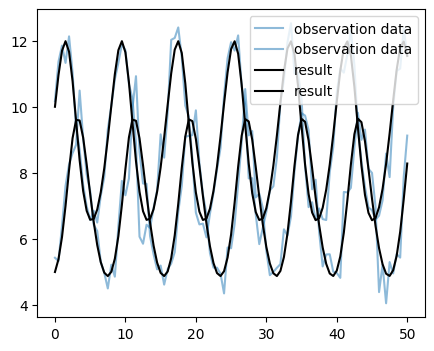

In [21]:
# Put everything in place for running the simulation
sim2.dispatch_constructor()

try:

    # Create an evaluator, run the simulation and obtain the results
    evaluator2 = sim2.dispatch(theta={"delta":0.9})
    evaluator2()

    # Plot the results
    fig, ax = plt.subplots(figsize=(5, 4))
    data_res2 = evaluator2.results
    ax.plot(data_obs.time, data_obs.prey, ls="-", color="tab:blue", alpha=.5, label ="observation data")
    ax.plot(data_obs.time, data_obs.predator, ls="-", color="tab:blue", alpha=.5, label ="observation data")
    ax.plot(data_res2.time, data_res2.prey, color="black", label ="result")
    ax.plot(data_res2.time, data_res2.predator, color="black", label ="result")
    ax.legend()

except ValueError as e:

    # Print the error message
    print("An error occurred:", type(e).__name__, ":", e)

👉 If you chose to ignore the note about {method}`pymob.sim.parse_input()` in the beginning of this notebook and added the initial conditions manually, you should see the following error message now:

```
ValueError: vmap in_axes must be an int, None, or a tuple of entries corresponding to the positional arguments passed to the function, but got len(in_axes)=6, len(args)=4
```

👉 The reason for this is that our model takes four parameters ($\alpha, \beta, \gamma, \delta$) along with two initial conditions (for prey and predator, respectively) but we only gave it the model parameters. If we had chosen the {method}`pymob.sim.parse_input()` formulation before, we would have run the following line of code:

```
sim.config.simulation.y0 = ["prey=10", "predator=5"]
```

👉 In this case, the function {meth}`pymob.SimulationBase.initialize()` above would have run {method}`pymob.sim.parse_input()` and added the initial condition $X = 10, Y = 5$ to `sim2`. But in our case, because the initial condition has never been defined in the configuration, this doesn't happen and we get this error. If you ran into this problem, run the following cell which sets the initial conditions manually. Otherwise, just scroll past it.

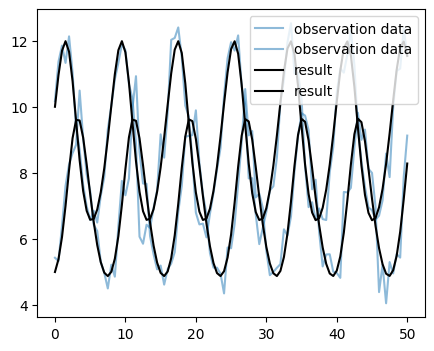

In [22]:
y0_obs_1 = xr.DataArray(10).to_dataset(name="prey")
y0_obs_2 = xr.DataArray(5).to_dataset(name="predator")
y0_obs = xr.merge([y0_obs_1, y0_obs_2])

sim2.model_parameters["y0"] = y0_obs

# Put everything in place for running the simulation
sim2.dispatch_constructor()

try:

    # Create an evaluator, run the simulation and obtain the results
    evaluator2 = sim2.dispatch(theta={"delta":0.9})
    evaluator2()

    # Plot the results
    fig, ax = plt.subplots(figsize=(5, 4))
    data_res2 = evaluator2.results
    ax.plot(data_obs.time, data_obs.prey, ls="-", color="tab:blue", alpha=.5, label ="observation data")
    ax.plot(data_obs.time, data_obs.predator, ls="-", color="tab:blue", alpha=.5, label ="observation data")
    ax.plot(data_res2.time, data_res2.prey, color="black", label ="result")
    ax.plot(data_res2.time, data_res2.predator, color="black", label ="result")
    ax.legend()

except ValueError as e:

    # Print the error message
    print("An error occurred:", type(e).__name__, ":", e)

👉 Now let's start the parameter inference again. The result should be the same as before.

Jax 64 bit mode: False
Absolute tolerance: 1e-07


C:\Users\Markus\pymob\pymob\pymob\inference\numpyro_backend.py:552: UserWarning: Model is not rendered, because the graphviz executable is not found. Try search for 'graphviz executables not found' and the used OS. This should be an easy fix :-)
  warnings.warn(


      Trace Shapes:      
       Param Sites:      
      Sample Sites:      
         delta dist     |
              value     |
    sigma_prey dist     |
              value     |
sigma_predator dist     |
              value     |
      prey_obs dist 101 |
              value 101 |
  predator_obs dist 101 |
              value 101 |


sample: 100%|██████████| 3000/3000 [00:21<00:00, 139.49it/s, 15 steps of size 4.32e-01. acc. prob=0.93]



                      mean       std    median      5.0%     95.0%     n_eff     r_hat
           delta      0.90      0.00      0.90      0.89      0.90   2707.28      1.00
  sigma_predator      0.52      0.04      0.52      0.46      0.58   1255.02      1.00
      sigma_prey      0.44      0.03      0.43      0.39      0.49   1217.63      1.00

Number of divergences: 0


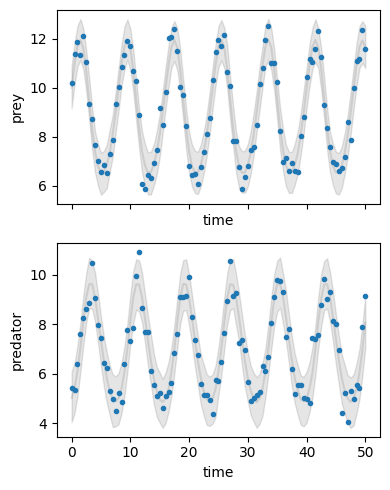

In [23]:
# Create the inferer (NumPyro backend, NUTS kernel) and let it do its work
sim2.set_inferer("numpyro")
sim2.inferer.config.inference_numpyro.kernel = "nuts"
sim2.inferer.run()

# Plot the results
sim2.config.simulation.x_dimension = "time"
sim2.posterior_predictive_checks(pred_hdi_style={"alpha": 0.1})

## 2.3 Summary

👉 Creating the simulation from a pre-saved configuration saved us the following steps:

- Adding data to the simulation
- If done right: Adding initial conditions to the simulation
- Creating the Lotka-Volterra parameters
- Specifying the error model along with the corresponding parameters
- Telling the evaluator not to throw exceptions if max_steps is exceeded
- Chossing a prior for parameter inference

👉 We still had to:

- Define a model
- Pass parameter values to the simulation
- Specify the solver

👉 By subclassing {class}`pymob.SimulationBase`, even those last steps can be avoided. This will be explained in detail in another tutorial as it mostly makes sense in the context of __case studies__. But in this case, it is pretty straightforward, so here's a little sneak peek:

In [24]:
# Define the simulation class
class LotkaVolterraSim(SimulationBase):
    model = lotkavolterra
    solver = JaxSolver
    def initialize(self, input=None):
        super().initialize(input)
        self.model_parameters["parameters"] = self.config.model_parameters.value_dict
        self.dispatch_constructor()
    
# Create and initialize simulation (no further steps necessary)
sim3 = LotkaVolterraSim("case_studies/ODEtutorial/scenarios/lotkavolterra/settings.cfg")
sim3.initialize()

MinMaxScaler(variable=prey, min=5.844172888098338, max=12.52594869826619)
MinMaxScaler(variable=predator, min=4.053933700151361, max=10.925258075625722)


C:\Users\Markus\pymob\pymob\pymob\simulation.py:1385: UserWarning: Using default initialize method, (load observations, define 'y0', define 'x_in'). This may be insufficient for more complex simulations.
  warnings.warn(


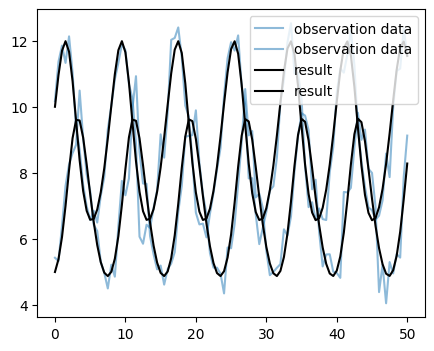

In [25]:
# Put everything in place for running the simulation
sim3.dispatch_constructor()

try:

    # Create an evaluator, run the simulation and obtain the results
    evaluator3 = sim3.dispatch(theta={"delta":0.9})
    evaluator3()

    # Plot the results
    fig, ax = plt.subplots(figsize=(5, 4))
    data_res3 = evaluator3.results
    ax.plot(data_obs.time, data_obs.prey, ls="-", color="tab:blue", alpha=.5, label ="observation data")
    ax.plot(data_obs.time, data_obs.predator, ls="-", color="tab:blue", alpha=.5, label ="observation data")
    ax.plot(data_res3.time, data_res3.prey, color="black", label ="result")
    ax.plot(data_res3.time, data_res3.predator, color="black", label ="result")
    ax.legend()

except ValueError as e:

    # Print the error message
    print("An error occurred:", type(e).__name__, ":", e)

Jax 64 bit mode: False
Absolute tolerance: 1e-07


C:\Users\Markus\pymob\pymob\pymob\inference\numpyro_backend.py:552: UserWarning: Model is not rendered, because the graphviz executable is not found. Try search for 'graphviz executables not found' and the used OS. This should be an easy fix :-)
  warnings.warn(


      Trace Shapes:      
       Param Sites:      
      Sample Sites:      
         delta dist     |
              value     |
    sigma_prey dist     |
              value     |
sigma_predator dist     |
              value     |
      prey_obs dist 101 |
              value 101 |
  predator_obs dist 101 |
              value 101 |


sample: 100%|██████████| 3000/3000 [00:20<00:00, 143.84it/s, 15 steps of size 4.32e-01. acc. prob=0.93]



                      mean       std    median      5.0%     95.0%     n_eff     r_hat
           delta      0.90      0.00      0.90      0.89      0.90   2707.28      1.00
  sigma_predator      0.52      0.04      0.52      0.46      0.58   1255.02      1.00
      sigma_prey      0.44      0.03      0.43      0.39      0.49   1217.63      1.00

Number of divergences: 0


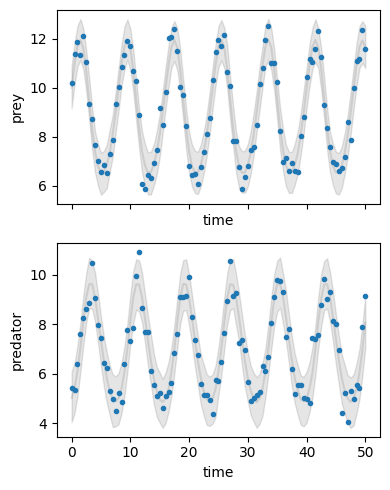

In [26]:
# Create the inferer (NumPyro backend, NUTS kernel) and let it do its work
sim3.set_inferer("numpyro")
sim3.inferer.config.inference_numpyro.kernel = "nuts"
sim3.inferer.run()

# Plot the results
sim3.config.simulation.x_dimension = "time"
sim3.posterior_predictive_checks(pred_hdi_style={"alpha": 0.1})